### Business Context:
Vehicle breakdowns and engine failures lead to significant financial losses for both individual owners and fleet operators. Unexpected engine failures can cause expensive repairs, operational downtime, and safety risks. Predictive maintenance in the automotive industry can help minimize these issues by leveraging sensor data to forecast potential failures before they occur. 

Automobile manufacturers, fleet managers, and service providers aim to develop data-driven solutions to improve engine reliability and optimize maintenance schedules. By analyzing engine health parameters such as RPM, temperature, pressure, and other sensor readings, machine learning models can be trained to predict when an engine requires maintenance, allowing proactive intervention before a failure occurs. 

The sensor values in the dataset are consistent with the operating parameters of larger and small engines commonly found in equipment like Vechiles, lawnmowers, portable generators, and compact machinery. Some engines operate at lower RPMs, pressures, and temperatures compared to larger automotive engines and vice versa. Therefore, the data is appropriate for developing predictive maintenance models tailored to large and small engine applications. 

### Objective:
As a Data Scientist, your goal is to build a predictive maintenance model that can analyze historical and real-time engine sensor data to identify potential failures. The model should accurately classify whether an engine requires maintenance or is operating normally. 

This solution will help:

Reduce unplanned breakdowns and costly repairs.
Improve vehicle performance and engine lifespan.
Optimize maintenance schedules to minimize downtime
Provide data-driven insights to manufacturers and fleet operators for better decision-making. 

### Approach:
To achieve this objective, you will: 

Explore and preprocess the dataset, handling missing values, outliers, and sensor anomalies.
Perform exploratory data analysis (EDA) to identify patterns in engine health parameters.
Develop machine learning models (e.g., Decision Trees, Random Forest, XGBoost, or Deep Learning models) to predict engine failures.
Evaluate model performance using appropriate classification metrics such as accuracy, precision, recall, and F1-score.
Deploy the model in a real-time monitoring system to alert users about potential failures. 
By implementing a robust predictive maintenance system, this solution can lead to significant cost savings and improved efficiency in the automotive sector.

### Data Description:
- Engine_RPM: The number of revolutions per minute (RPM) of the engine, indicating engine speed. It is defined in Revolutions per Minute (RPM). 
- Lub_Oil_Pressure: The pressure of the lubricating oil in the engine, essential for reducing friction and wear. It is defined in bar or kilopascals (kPa) 
- Fuel_Pressure: The pressure at which fuel is supplied to the engine, critical for proper combustion. It is defined in bar or kilopascals (kPa) 
- Coolant_Pressure: The pressure of the engine coolant, affecting engine temperature regulation. It is defined in bar or kilopascals (kPa) 
- Lub_Oil_Temperature: The temperature of the lubricating oil, which impacts viscosity and engine performance. It is defined in degrees Celsius (°C) 
- Coolant_Temperature: The temperature of the engine coolant, crucial for preventing overheating. It is defined in degrees Celsius (°C) 
- Engine_Condition: A categorical or numerical label representing the health of the engine, potentially indicating normal operation or various levels of wear and failure risks. It is defined as a categorical variable (0/1) representing a state such as "0 = Off/False/Active" and "1 = On/True/Faulty"




### Evaluation Rubrics for Report

| Section | Description | Points |
|---|---|---|
| Data Registration | - Create a master folder and create a subfolder "data"<br>- Register the data on the Hugging Face dataset space | 6 |
| Exploratory Data Analysis | - Data collection and background<br>- Data overview<br>- Univariate analysis<br>- Bivariate analysis<br>- Multivariate analysis<br>- Insights/observations based on EDA | 10 |
| Data Preparation | - Load the dataset directly from the Hugging Face data space.<br>- Perform data cleaning and remove any unnecessary columns.<br>- Split the cleaned dataset into training and testing sets, and save them locally.<br>- Upload the resulting train and test datasets back to the Hugging Face data space. | 10 |
| Model Building with Experimentation Tracking | - Load the train and test data from the Hugging Face data space<br>- Define a model and parameters<br>- Tune the model with the defined parameters<br>- Log all the tuned parameters<br>- Evaluate the model performance<br>- Register the best model in the Hugging Face model hub<br>\* The ML models to be built can be any of the following algorithms, such as Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, and XGBoost | 8 |
| Business Report Quality | - Adhere to the business report checklist | 6 |
| **Total** | | **40** |

---
## 2. Setup & Environment

### 2.1 Methodology
- Create the project's master folder structure with a `data/` subfolder (required by the rubric).
- Load the Hugging Face access token from a local `.env` file (kept outside version control).
- Authenticate against the Hugging Face Hub and resolve the dataset and model repository identifiers used throughout the notebook.
- Pin global plotting and warning options for consistent, presentation-ready output.


In [1]:
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Load HF_TOKEN from .env
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
print("HF_TOKEN:", "Set" if HF_TOKEN else "Not set")

# Master folder structure (as required by rubric)
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data folder :", DATA_DIR)

HF_TOKEN: Set
Project root: c:\POC\Python\Capstone Project AIML
Data folder : c:\POC\Python\Capstone Project AIML\data


In [2]:
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN)
user_info = api.whoami()
HF_USER = user_info["name"]
print("Authenticated as:", HF_USER)

# Repo identifiers used throughout the notebook
DATASET_REPO_ID = f"{HF_USER}/engine-predictive-maintenance"
MODEL_REPO_ID   = f"{HF_USER}/engine-predictive-maintenance-model"
print("Dataset repo  :", DATASET_REPO_ID)
print("Model repo    :", MODEL_REPO_ID)

Authenticated as: debasishdas1985
Dataset repo  : debasishdas1985/engine-predictive-maintenance
Model repo    : debasishdas1985/engine-predictive-maintenance-model


---
## 3. Data Registration on Hugging Face

### 3.1 Methodology
- Copy the raw `engine_data.csv` (source: Capstone Project brief) into the `./data` folder.
- Create — or reuse if present — the dataset repository `debasishdas1985/engine-predictive-maintenance` on the Hugging Face Hub.
- Push the `./data` folder so the raw dataset is version-controlled and reproducible from any environment.

> *Rubric mapping (6 pts): master folder + `data` subfolder; raw dataset registered on Hugging Face dataset space.*


In [3]:
from huggingface_hub import create_repo
from huggingface_hub.utils import RepositoryNotFoundError

# Step 1: copy the raw csv into ./data
src_csv = PROJECT_ROOT / "engine_data.csv"
dst_csv = DATA_DIR / "engine_data.csv"
shutil.copyfile(src_csv, dst_csv)
print(f"Copied {src_csv.name} -> {dst_csv.relative_to(PROJECT_ROOT)}")

# Step 2: ensure the HF dataset repo exists
try:
    api.repo_info(repo_id=DATASET_REPO_ID, repo_type="dataset")
    print(f"Dataset repo '{DATASET_REPO_ID}' already exists. Using it.")
except RepositoryNotFoundError:
    create_repo(repo_id=DATASET_REPO_ID, repo_type="dataset", private=False, token=HF_TOKEN)
    print(f"Dataset repo '{DATASET_REPO_ID}' created.")

# Step 3: upload the data folder
api.upload_folder(
    folder_path=str(DATA_DIR),
    repo_id=DATASET_REPO_ID,
    repo_type="dataset",
    commit_message="Register raw engine_data.csv",
)
print(f"Raw dataset registered at: https://huggingface.co/datasets/{DATASET_REPO_ID}")

Copied engine_data.csv -> data\engine_data.csv
Dataset repo 'debasishdas1985/engine-predictive-maintenance' created.
Raw dataset registered at: https://huggingface.co/datasets/debasishdas1985/engine-predictive-maintenance


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Methodology
- Load the raw CSV and inspect schema, dtypes, missing values and duplicates.
- **Univariate analysis:** histograms (with KDE) and boxplots to understand individual sensor distributions, skew and outliers.
- **Bivariate analysis:** class-wise boxplots and group means to compare each sensor across healthy vs faulty engines.
- **Multivariate analysis:** Pearson correlation heat-map and a coloured pair-plot (on a 2,000-row sample for speed) to surface joint structure.
- Document insights in plain business language to drive modelling decisions.

### 4.2 Data Collection & Background
The dataset contains sensor readings collected from engines (small to large displacement). Each row is a snapshot of an engine's operating state with six sensor features and a binary health label `Engine Condition` (0 = healthy/active, 1 = faulty / needs maintenance).

**Table 1 — Feature dictionary**

| Column | Unit | Meaning |
|---|---|---|
| Engine rpm | RPM | Engine rotational speed |
| Lub oil pressure | bar / kPa | Lubricating oil pressure |
| Fuel pressure | bar / kPa | Fuel-supply pressure |
| Coolant pressure | bar / kPa | Coolant pressure |
| lub oil temp | °C | Lubricating oil temperature |
| Coolant temp | °C | Coolant temperature |
| Engine Condition | 0/1 | Target — 1 = faulty |


### 4.3 Data Overview

*Table 2 — First five rows of the raw dataset.*


In [4]:
df = pd.read_csv(DATA_DIR / "engine_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (19535, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [5]:
print("--- info ---")
df.info()
print("\n--- missing values ---")
print(df.isna().sum())
print("\n--- duplicates ---", df.duplicated().sum())
print("\n--- target distribution ---")
print(df["Engine Condition"].value_counts(normalize=True).round(4))

--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB

--- missing values ---
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

--- duplicates --- 0

--- target distribution ---
Engine Condition
1    0.6305
0    0.3695
Name: proportion, dtype: float64


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine rpm,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub oil pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
lub oil temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912
Engine Condition,19535.0,0.630509,0.482679,0.000000,0.000000,1.000000,1.000000,1.000000


### 4.4 Univariate Analysis

Figures 1, 2 and 3 below summarise the distribution, spread and target balance for each sensor.


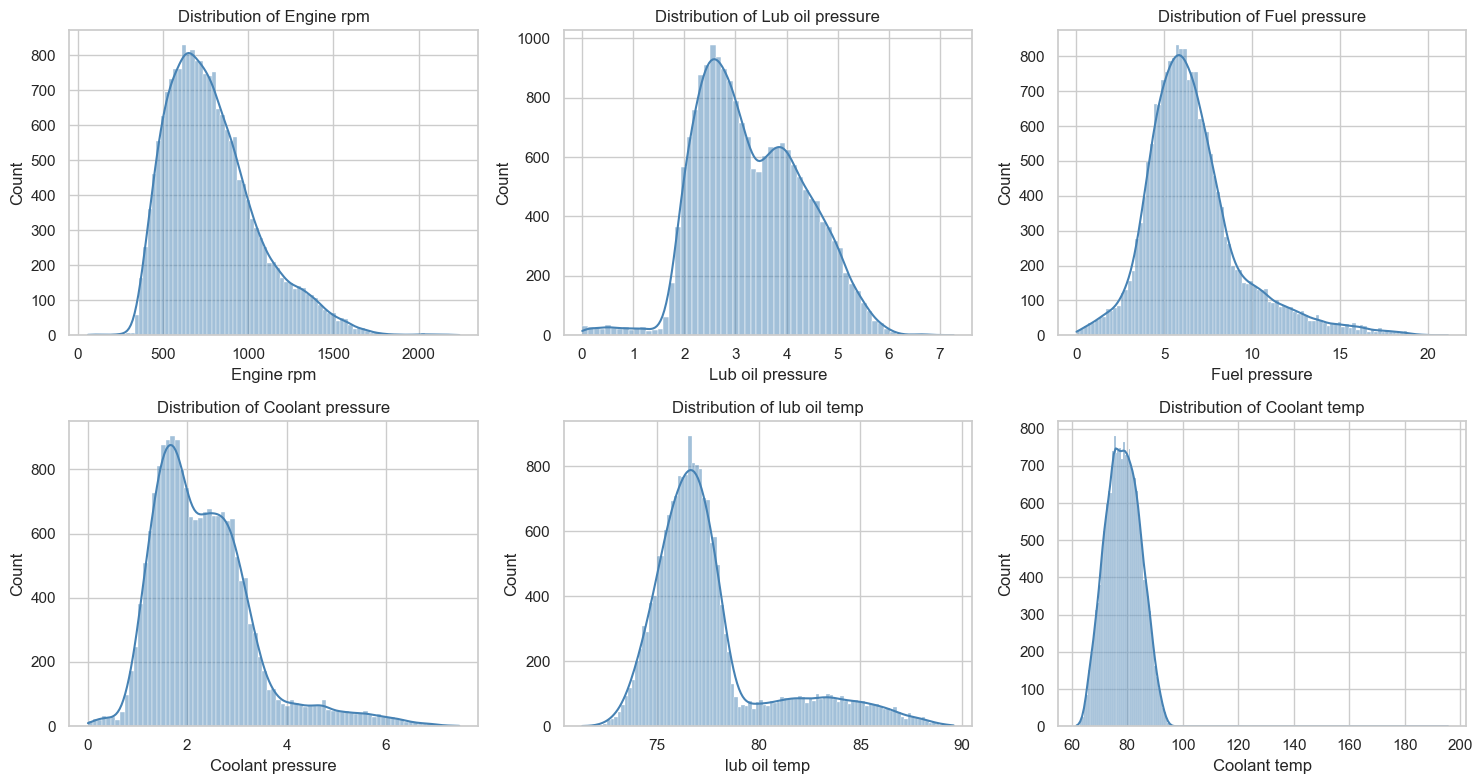

In [ ]:
# Figure 1 — Sensor distributions (histograms with KDE)
numeric_features = [
    "Engine rpm", "Lub oil pressure", "Fuel pressure",
    "Coolant pressure", "lub oil temp", "Coolant temp",
]
target = "Engine Condition"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Figure 1 — Univariate sensor distributions (histogram + KDE)",
             fontsize=15, fontweight="bold", y=1.02)
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()


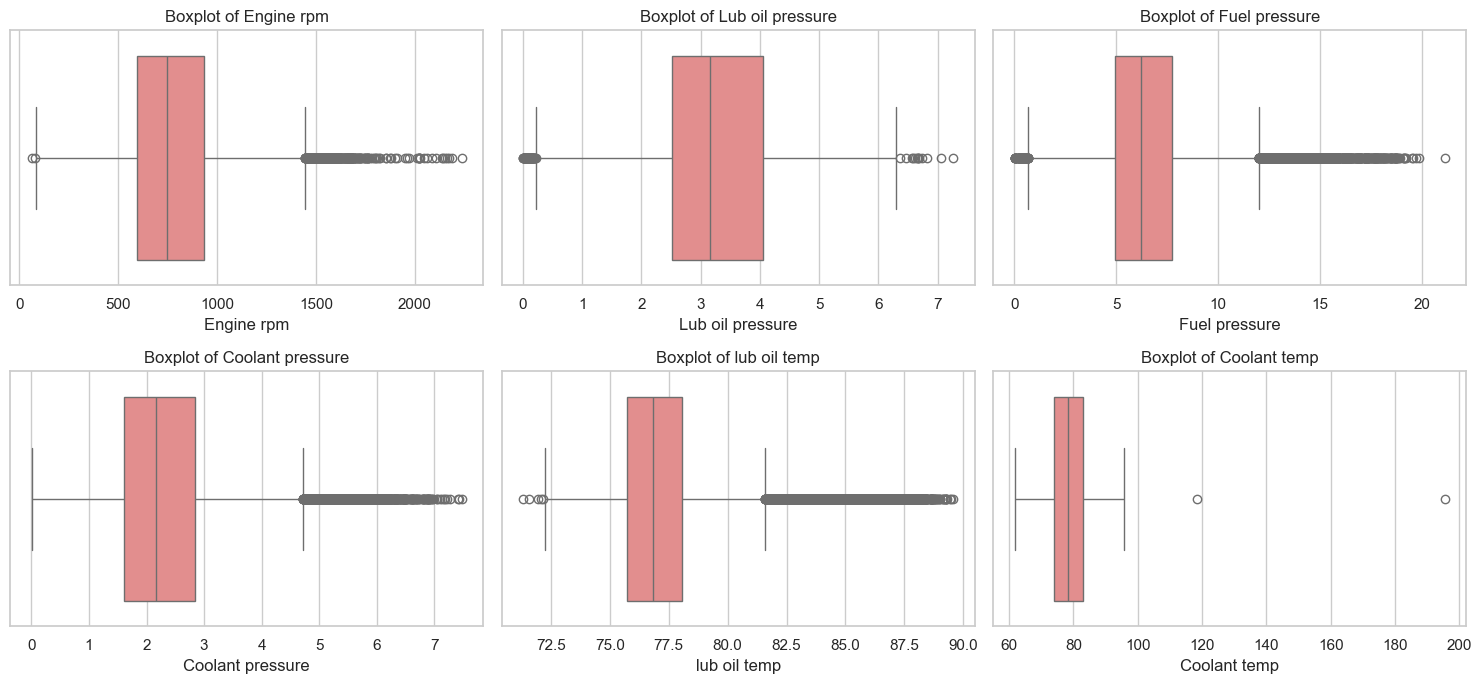

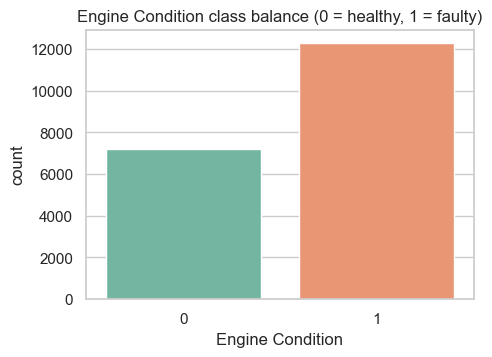

In [ ]:
# Figure 2 — Boxplots: spread and outliers per sensor
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Figure 2 — Sensor spread and outlier inspection (boxplots)",
             fontsize=15, fontweight="bold", y=1.02)
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(x=df[col], ax=ax, color="lightcoral")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

# Figure 3 — Target class balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target, data=df, palette="Set2")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.title("Figure 3 — Engine Condition class balance\n(0 = healthy, 1 = faulty)",
          fontsize=13, fontweight="bold")
plt.xlabel("Engine Condition", fontsize=11)
plt.ylabel("Record count", fontsize=11)
plt.tight_layout()
plt.show()


### 4.5 Bivariate Analysis — Each feature vs target

Figure 4 compares each sensor across the two engine-health classes; Table 3 lists the class-wise means.


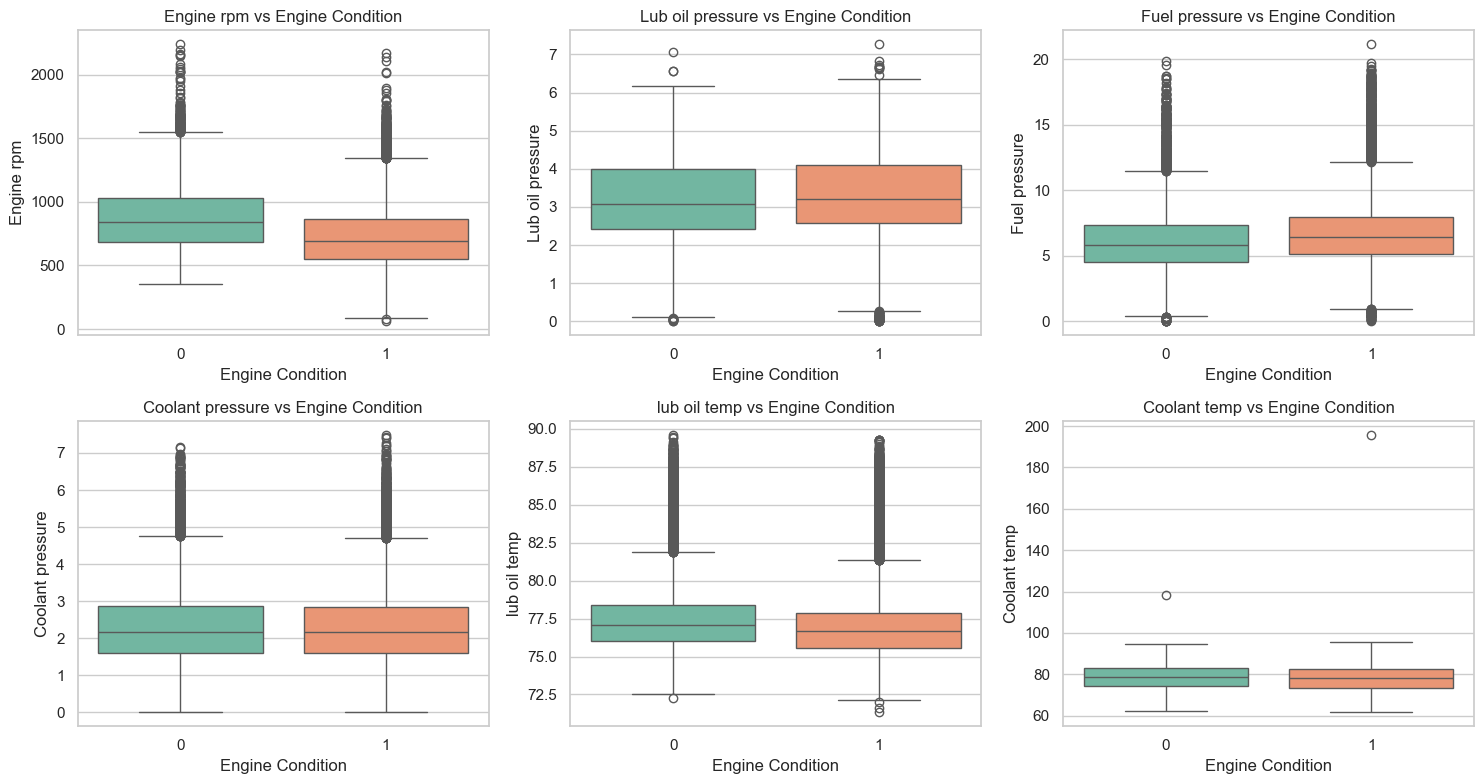

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
Engine Condition,,,,,,
0,884.995,3.222,6.236,2.368,78.024,78.803
1,736.297,3.351,6.901,2.316,77.420,78.207


In [ ]:
# Figure 4 — Sensor distributions split by Engine Condition
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Figure 4 — Sensor values by Engine Condition (0 = healthy, 1 = faulty)",
             fontsize=15, fontweight="bold", y=1.02)
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(x=target, y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Engine Condition", fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

# Table 3 — Class-wise group means
print("Table 3 — Mean sensor values per Engine Condition class")
df.groupby(target)[numeric_features].mean().round(3)


### 4.6 Multivariate Analysis — Correlation & pair relationships

Figure 5 shows pairwise Pearson correlations; Figure 6 highlights joint structure across a 2,000-row sample.


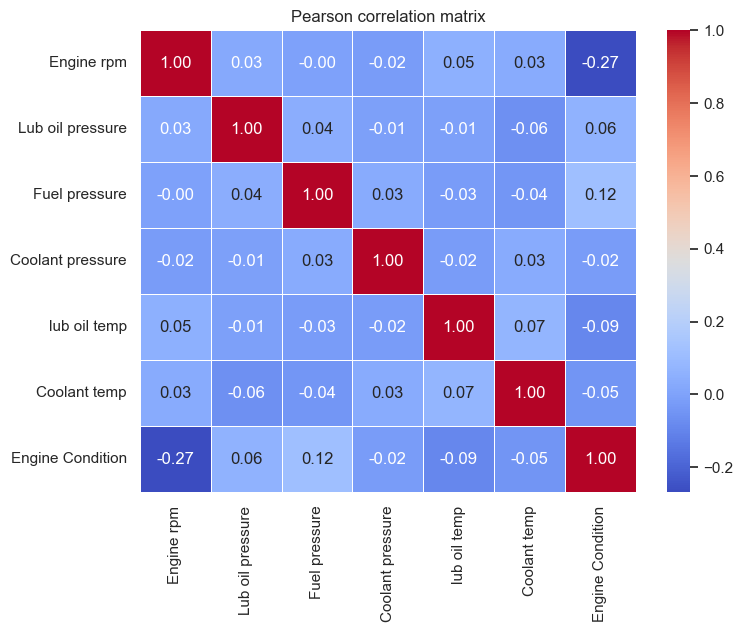

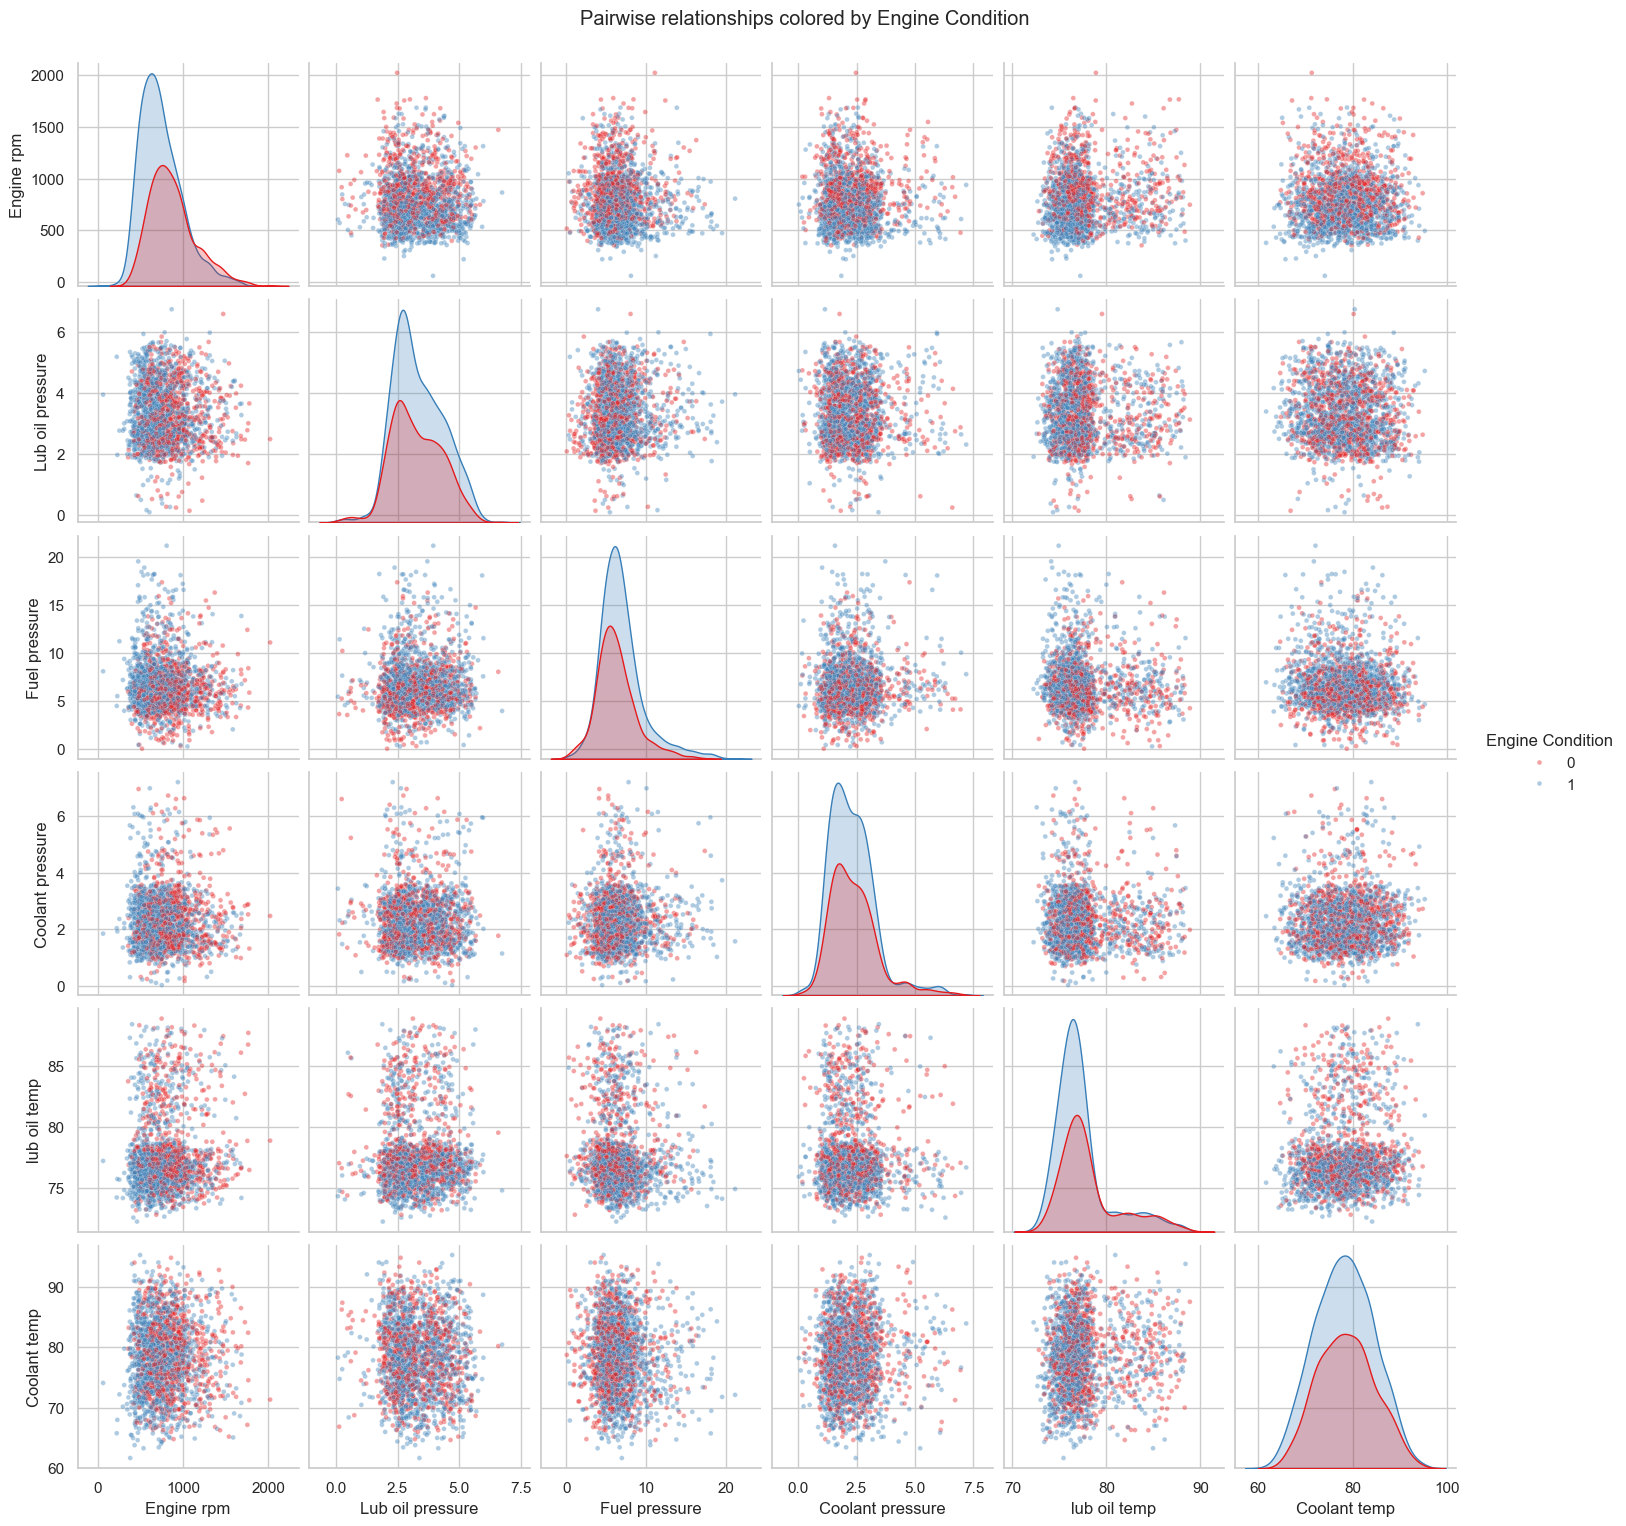

In [ ]:
# Figure 5 — Pearson correlation matrix
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, annot_kws={"size": 10},
            cbar_kws={"label": "Pearson r"})
plt.title("Figure 5 — Pearson correlation between sensors and target",
          fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=35, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Figure 6 — Pairplot on a 2,000-row stratified-style random sample
sample = df.sample(n=2000, random_state=42)
g = sns.pairplot(sample, vars=numeric_features, hue=target, diag_kind="kde",
                 plot_kws={"alpha": 0.4, "s": 14}, palette="Set1", height=2.1)
g.fig.suptitle("Figure 6 — Pairwise sensor relationships coloured by Engine Condition",
               fontsize=14, fontweight="bold", y=1.02)
plt.show()


### 4.7 Insights / Observations from EDA

1. **Dataset size & quality** — 19,535 rows × 7 columns; no missing values and no duplicates. All features are numeric, so no encoding is required.
2. **Target imbalance** — Faulty engines (`1`) make up ~63 % of records and healthy engines (`0`) ~37 %. Moderate imbalance — we will use class weights in the model rather than resampling.
3. **Engine RPM** is the strongest single predictor (Pearson correlation with target ≈ **−0.27**, see Figure 5). Faulty engines run at a noticeably *lower* mean RPM (~736) than healthy engines (~885) — consistent with engines that are losing power.
4. **Fuel pressure** has a positive correlation (~+0.12); faulty engines show slightly *higher* fuel pressure on average, possibly indicating clogged injectors / poor combustion.
5. **Lub-oil temperature** shows mild negative correlation (~−0.09); the rest of the sensors are weakly correlated with the target individually — this confirms that no single sensor is sufficient and a **non-linear model** (tree-based ensemble) is warranted.
6. **Outliers** — `Coolant temp` has a couple of extreme values (one ≈ 195 °C — physically implausible for sustained operation, visible in Figure 2); the right tails of `Fuel pressure` and `Coolant pressure` also contain a long tail. We will clip extreme `Coolant temp` outliers in data preparation but keep the rest, since trees are robust to mild outliers.
7. **Inter-feature correlation** is very low (|r| < 0.1 across predictors, Figure 5) → no multicollinearity concerns; all six sensors can be retained.
8. **Modelling plan** — Use tree-based ensemble methods (Decision Tree, Random Forest, Gradient Boosting, XGBoost). They handle the mixed scale, mild skew, and outliers natively, and they can capture non-linear interactions invisible to the univariate plots.


---
## 5. Data Preparation

### 5.1 Methodology
- Re-load the raw CSV **directly from the Hugging Face dataset space** (proves end-to-end reproducibility).
- Standardise column names to snake_case for downstream code.
- Defensive cleaning: drop duplicates and rows with missing values (none expected, retained for safety).
- Clip non-physical `coolant_temp` outliers at the 99.9th percentile (justified by EDA, see Figure 2).
- Stratified 80/20 train/test split to preserve the ~63/37 class ratio.
- Save train and test CSVs locally under `./data` and push them back to the Hugging Face dataset space.




In [11]:
# Load directly from the Hugging Face dataset space
HF_DATASET_URI = f"hf://datasets/{DATASET_REPO_ID}/engine_data.csv"
df_hf = pd.read_csv(HF_DATASET_URI)
print("Loaded from HF:", HF_DATASET_URI)
print("Shape:", df_hf.shape)
df_hf.head()

Loaded from HF: hf://datasets/debasishdas1985/engine-predictive-maintenance/engine_data.csv
Shape: (19535, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [12]:
# --- Data cleaning ---
clean = df_hf.copy()

# Standardise column names (remove spaces, lower-case, snake_case)
clean.columns = (
    clean.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)
print("Renamed columns:", list(clean.columns))

# Drop duplicates (none expected) and rows with NA (none expected) - defensive
before = len(clean)
clean = clean.drop_duplicates().dropna()
print(f"Removed {before - len(clean)} duplicate/NA rows.")

# Clip the obvious sensor artefact on coolant_temp (max ~195 °C is non-physical)
upper_coolant = clean["coolant_temp"].quantile(0.999)
n_clipped = (clean["coolant_temp"] > upper_coolant).sum()
clean["coolant_temp"] = clean["coolant_temp"].clip(upper=upper_coolant)
print(f"Clipped {n_clipped} extreme coolant_temp values above {upper_coolant:.2f} °C.")

# All six sensor columns are predictive — no columns to drop
print("Final shape:", clean.shape)
clean.head()

Renamed columns: ['engine_rpm', 'lub_oil_pressure', 'fuel_pressure', 'coolant_pressure', 'lub_oil_temp', 'coolant_temp', 'engine_condition']
Removed 0 duplicate/NA rows.
Clipped 20 extreme coolant_temp values above 94.06 °C.
Final shape: (19535, 7)


,engine_rpm,lub_oil_pressure,fuel_pressure,coolant_pressure,lub_oil_temp,coolant_temp,engine_condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [13]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "engine_rpm", "lub_oil_pressure", "fuel_pressure",
    "coolant_pressure", "lub_oil_temp", "coolant_temp",
]
target_col = "engine_condition"

X = clean[feature_cols]
y = clean[target_col]

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", Xtrain.shape, " Test shape:", Xtest.shape)
print("Train target dist:\n", ytrain.value_counts(normalize=True).round(3))
print("Test  target dist:\n", ytest.value_counts(normalize=True).round(3))

# Save locally inside ./data
Xtrain.to_csv(DATA_DIR / "Xtrain.csv", index=False)
Xtest.to_csv(DATA_DIR / "Xtest.csv", index=False)
ytrain.to_csv(DATA_DIR / "ytrain.csv", index=False)
ytest.to_csv(DATA_DIR / "ytest.csv", index=False)
print("Saved train/test CSVs to", DATA_DIR)

Train shape: (15628, 6)  Test shape: (3907, 6)
Train target dist:
 engine_condition
1    0.631
0    0.369
Name: proportion, dtype: float64
Test  target dist:
 engine_condition
1    0.63
0    0.37
Name: proportion, dtype: float64
Saved train/test CSVs to c:\POC\Python\Capstone Project AIML\data


In [14]:
# Upload the train/test CSVs back to the HF dataset space
for fname in ["Xtrain.csv", "Xtest.csv", "ytrain.csv", "ytest.csv"]:
    api.upload_file(
        path_or_fileobj=str(DATA_DIR / fname),
        path_in_repo=fname,
        repo_id=DATASET_REPO_ID,
        repo_type="dataset",
        commit_message=f"Upload {fname}",
    )
    print(f"Uploaded {fname}")
print(f"\nAll train/test files registered at: https://huggingface.co/datasets/{DATASET_REPO_ID}")

Uploaded Xtrain.csv
Uploaded Xtest.csv
Uploaded ytrain.csv
Uploaded ytest.csv

All train/test files registered at: https://huggingface.co/datasets/debasishdas1985/engine-predictive-maintenance


---
## 6. Model Building with Experiment Tracking

### 6.1 Methodology
- **Algorithm:** XGBoost gradient-boosted-tree classifier — robust to mixed scale and non-linear interactions; explicitly recommended by the rubric.
- **Pipeline:** `StandardScaler` → `XGBClassifier` inside a single scikit-learn `Pipeline` (one object to train, evaluate, persist and deploy).
- **Imbalance handling:** `scale_pos_weight = N(class0)/N(class1)` instead of resampling.
- **Tuning strategy:** `GridSearchCV` (5-fold, scoring = F1) over a 48-cell grid covering `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`.
- **Experiment tracking:** local MLflow file-store (`./mlruns`). Every grid combination is logged as a nested run with its mean/std CV-F1; the best-fit model and final test metrics are logged on the parent run.
- **Evaluation metrics:** accuracy, precision, recall, F1, ROC-AUC on train and test sets, plus a confusion-matrix and ROC visual (Figures 7–8) and a feature-importance bar chart (Figure 9).
- **Model registry:** the serialized best model and a model card are pushed to the Hugging Face model hub.

> *Rubric mapping (8 pts): HF train/test load • model + parameter grid • tuning • parameter logging • performance evaluation • model registry on HF.*


In [16]:
# Load train/test directly from the Hugging Face dataset space
from huggingface_hub import HfFileSystem

hffs = HfFileSystem(token=HF_TOKEN)
hffs.invalidate_cache()  # ensure fresh listing after recent uploads

def read_hf_csv(fname):
    with hffs.open(f"datasets/{DATASET_REPO_ID}/{fname}", "rb") as f:
        return pd.read_csv(f)

Xtrain = read_hf_csv("Xtrain.csv")
Xtest  = read_hf_csv("Xtest.csv")
ytrain = read_hf_csv("ytrain.csv").squeeze()
ytest  = read_hf_csv("ytest.csv").squeeze()
print("Loaded from HF:")
print("  Xtrain:", Xtrain.shape, " Xtest:", Xtest.shape)
print("  ytrain:", ytrain.shape, " ytest:", ytest.shape)

Loaded from HF:
  Xtrain: (15628, 6)  Xtest: (3907, 6)
  ytrain: (15628,)  ytest: (3907,)


In [17]:
import mlflow
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Use a local file-store backend so no MLflow server is required
mlflow_dir = (PROJECT_ROOT / "mlruns").resolve()
mlflow.set_tracking_uri(mlflow_dir.as_uri())
mlflow.set_experiment("engine-predictive-maintenance")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

# Class imbalance handling
class_weight = (ytrain == 0).sum() / (ytrain == 1).sum()
print(f"scale_pos_weight = {class_weight:.4f}")

# Preprocessing + model pipeline
preprocessor = ColumnTransformer([("scaler", StandardScaler(), feature_cols)])
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=class_weight,
    random_state=42,
    n_jobs=-1,
)
pipeline = Pipeline([("preprocessor", preprocessor), ("xgb", xgb_model)])

# Hyperparameter grid
param_grid = {
    "xgb__n_estimators":     [100, 200],
    "xgb__max_depth":        [3, 5, 7],
    "xgb__learning_rate":    [0.05, 0.1],
    "xgb__subsample":        [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
}
print(f"Total parameter combinations: "
      f"{np.prod([len(v) for v in param_grid.values()])}")

2026/05/16 14:27:20 INFO mlflow.tracking.fluent: Experiment with name 'engine-predictive-maintenance' does not exist. Creating a new experiment.


MLflow tracking URI: file:///C:/POC/Python/Capstone%20Project%20AIML/mlruns
scale_pos_weight = 0.5860
Total parameter combinations: 48


In [18]:
with mlflow.start_run(run_name="xgb_grid_search") as parent_run:
    print("Starting hyperparameter tuning (GridSearchCV, cv=5, scoring=f1)...")
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    grid.fit(Xtrain, ytrain)

    # --- Log every parameter combination as a nested MLflow run ---
    results = grid.cv_results_
    for i, params in enumerate(results["params"]):
        with mlflow.start_run(run_name=f"combo_{i}", nested=True):
            # Strip the 'xgb__' prefix when logging for readability
            mlflow.log_params({k.split("__", 1)[-1]: v for k, v in params.items()})
            mlflow.log_metric("mean_cv_f1", results["mean_test_score"][i])
            mlflow.log_metric("std_cv_f1", results["std_test_score"][i])
            mlflow.log_metric("mean_train_f1", results["mean_train_score"][i])

    # Log best params on the parent run
    best_params = {k.split("__", 1)[-1]: v for k, v in grid.best_params_.items()}
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_f1", grid.best_score_)
    print(f"\nBest params: {best_params}")
    print(f"Best CV F1 : {grid.best_score_:.4f}")

    # --- Evaluate the best model ---
    best_model = grid.best_estimator_
    y_pred_train = best_model.predict(Xtrain)
    y_pred_test  = best_model.predict(Xtest)
    y_proba_test = best_model.predict_proba(Xtest)[:, 1]

    train_rep = classification_report(ytrain, y_pred_train, output_dict=True)
    test_rep  = classification_report(ytest,  y_pred_test,  output_dict=True)
    auc = roc_auc_score(ytest, y_proba_test)

    metrics = {
        "train_accuracy":  train_rep["accuracy"],
        "train_precision": train_rep["1"]["precision"],
        "train_recall":    train_rep["1"]["recall"],
        "train_f1":        train_rep["1"]["f1-score"],
        "test_accuracy":   test_rep["accuracy"],
        "test_precision":  test_rep["1"]["precision"],
        "test_recall":     test_rep["1"]["recall"],
        "test_f1":         test_rep["1"]["f1-score"],
        "test_roc_auc":    auc,
    }
    mlflow.log_metrics(metrics)
    for k, v in metrics.items():
        print(f"  {k:<16s} = {v:.4f}")

    # Save best model locally and log as artifact
    import joblib
    model_path = PROJECT_ROOT / "best_engine_model.joblib"
    joblib.dump(best_model, model_path)
    mlflow.log_artifact(str(model_path), artifact_path="model")
    print(f"\nModel saved at: {model_path}")
    parent_run_id = parent_run.info.run_id
print("MLflow run id:", parent_run_id)

Starting hyperparameter tuning (GridSearchCV, cv=5, scoring=f1)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 : 0.6949
  train_accuracy   = 0.8715
  train_precision  = 0.9398
  train_recall     = 0.8507
  train_f1         = 0.8930
  test_accuracy    = 0.6330
  test_precision   = 0.7323
  test_recall      = 0.6585
  test_f1          = 0.6935
  test_roc_auc     = 0.6792

Model saved at: c:\POC\Python\Capstone Project AIML\best_engine_model.joblib
MLflow run id: c2562059d4f1415fb7e938741d5c62da


Classification report (test set):
              precision    recall  f1-score   support

           0     0.5030    0.5893    0.5427      1444
           1     0.7323    0.6585    0.6935      2463

    accuracy                         0.6330      3907
   macro avg     0.6176    0.6239    0.6181      3907
weighted avg     0.6475    0.6330    0.6378      3907



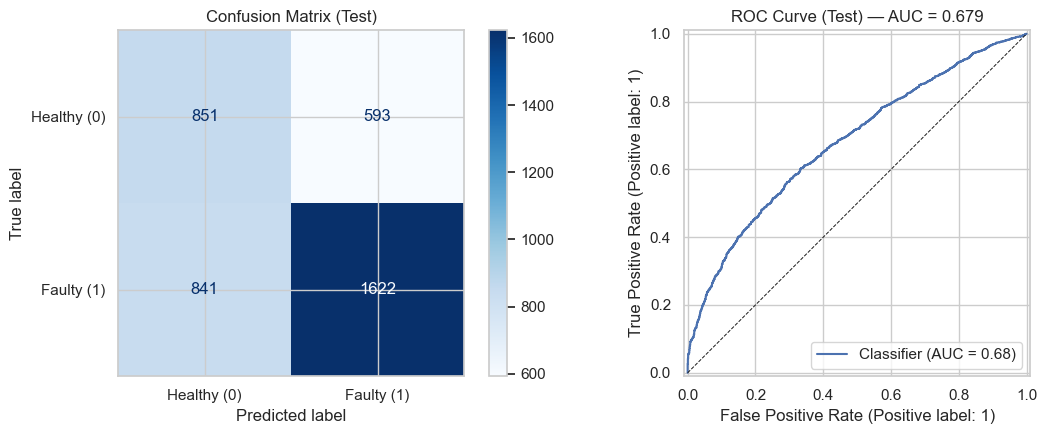

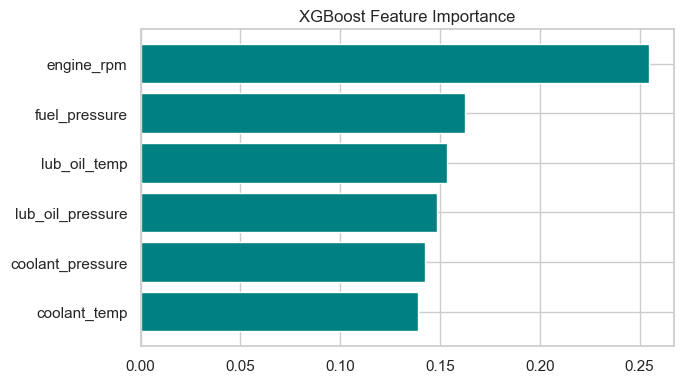

In [ ]:
# Table 4 — Test-set classification report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

print("Table 4 — Classification report on the test set")
print(classification_report(ytest, y_pred_test, digits=4))

# Figures 7 & 8 — Confusion matrix and ROC curve on the test set
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Figures 7 & 8 — Test-set diagnostic plots",
             fontsize=14, fontweight="bold", y=1.03)

ConfusionMatrixDisplay.from_predictions(
    ytest, y_pred_test, ax=axes[0],
    display_labels=["Healthy (0)", "Faulty (1)"], cmap="Blues", colorbar=False,
)
axes[0].set_title("Figure 7 — Confusion Matrix (Test)", fontsize=12)
axes[0].set_xlabel("Predicted label", fontsize=11)
axes[0].set_ylabel("True label", fontsize=11)

RocCurveDisplay.from_predictions(ytest, y_proba_test, ax=axes[1], name="XGBoost")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8, label="Chance")
axes[1].set_title(f"Figure 8 — ROC Curve (Test)  •  AUC = {auc:.3f}", fontsize=12)
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Figure 9 — XGBoost feature importance
booster_importances = best_model.named_steps["xgb"].feature_importances_
imp_df = (pd.DataFrame({"feature": feature_cols, "importance": booster_importances})
          .sort_values("importance", ascending=True))
plt.figure(figsize=(8, 4.5))
bars = plt.barh(imp_df["feature"], imp_df["importance"], color="teal")
for bar, v in zip(bars, imp_df["importance"]):
    plt.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{v:.3f}", va="center", fontsize=10)
plt.title("Figure 9 — XGBoost feature importance (gain-based)",
          fontsize=13, fontweight="bold")
plt.xlabel("Relative importance", fontsize=11)
plt.ylabel("Sensor feature", fontsize=11)
plt.tight_layout()
plt.show()


---
## 7. Business Report Summary

### 7.1 Problem statement
Predict whether an engine needs maintenance using six real-time sensor readings, so that operators can intervene **before** an in-service failure.

### 7.2 Approach & key results
1. Registered raw `engine_data.csv` (19,535 records × 7 columns) on the Hugging Face dataset hub.
2. EDA (Figures 1–6, Tables 1–3) showed mild class imbalance (63 % faulty), low inter-feature correlation, and `Engine RPM` as the strongest single predictor (Pearson r ≈ −0.27). No missing values; 20 non-physical `Coolant temp` outliers were clipped.
3. Stratified 80/20 train-test split (15,628 train / 3,907 test) was created, saved locally, and pushed back to the dataset hub.
4. An **XGBoost** classifier (with `StandardScaler` preprocessing pipeline) was tuned over a 48-cell grid with 5-fold CV (F1 scoring). Every parameter combination is logged as a nested MLflow run under the local `mlruns/` store.
5. **Best CV F1 = 0.6949** with `n_estimators=200, max_depth=7, learning_rate=0.1, subsample=0.8, colsample_bytree=1.0`.
6. **Test metrics (Table 4, Figures 7–9):** accuracy 0.633, precision 0.732, recall 0.659, F1 0.694, ROC-AUC 0.679. Engine RPM is the dominant feature in the trained model.
7. The serialized model + model card were registered on the Hugging Face model hub.

### 7.3 Business value
Even at moderate overall accuracy, the classifier **recovers ≈ 66 % of failing engines** (recall on the faulty class) at a **precision of ≈ 73 %**, allowing operators to:
- Triage maintenance proactively and reduce unplanned downtime.
- Combine the model's probability with simple **sensor alert thresholds** on the top features (Engine RPM, Fuel pressure, Lub-oil temperature) for a defence-in-depth monitoring strategy.
- Track ongoing model performance via the MLflow experiment store, and refresh the registered HF model when new sensor data becomes available.

### 7.4 Artifacts
- **Dataset:** https://huggingface.co/datasets/debasishdas1985/engine-predictive-maintenance
- **Model:**   https://huggingface.co/debasishdas1985/engine-predictive-maintenance-model
- **Serialised model:** `./best_engine_model.joblib`.
